In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
dataset = load_dataset("daniel3303/StoryReasoning", split="train")

texts = []
labels = []

for item in dataset:
    story = item["story"]
    
    for i, sentence in enumerate(story[:5]):
        texts.append(sentence)
        labels.append(i)

labels = np.array(labels)

print("Dataset size:", len(texts))

Dataset size: 17760


In [3]:
unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u+1}: {c}")

Class 1: 3552
Class 2: 3552
Class 3: 3552
Class 4: 3552
Class 5: 3552


In [4]:
VOCAB_SIZE = 10000
MAX_LENGTH = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post')

X_train, X_val, y_train, y_val = train_test_split(
    padded, labels, test_size=0.2, stratify=labels
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))

Train size: 14208
Validation size: 3552


In [5]:
def build_model(lstm_units=128, dropout=0.3, embedding_dim=128, second_lstm=False):
    
    model = tf.keras.Sequential()
    
    model.add(tf.keras.layers.Embedding(VOCAB_SIZE, embedding_dim, input_length=MAX_LENGTH))
    
    if second_lstm:
        model.add(tf.keras.layers.LSTM(lstm_units, return_sequences=True))
        model.add(tf.keras.layers.LSTM(lstm_units))
    else:
        model.add(tf.keras.layers.LSTM(lstm_units))
    
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))
    
    model.add(tf.keras.layers.Dense(64, activation='relu'))
    model.add(tf.keras.layers.Dense(5, activation='softmax'))
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

In [8]:
def train_and_evaluate(name, **kwargs):
    print(f"\n===== {name} =====")
    
    model = build_model(**kwargs)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=1
    )
    
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    
    # Plot
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(name)
    plt.legend()
    plt.show()
    
    return {
        "Experiment": name,
        "Train Loss": history.history['loss'][-1],
        "Val Loss": val_loss,
        "Val Accuracy": val_acc
    }


===== Baseline =====
Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.1970 - loss: 1.6108 - val_accuracy: 0.2002 - val_loss: 1.6097
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.2010 - loss: 1.6102 - val_accuracy: 0.2002 - val_loss: 1.6096
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2040 - loss: 1.6097 - val_accuracy: 0.2002 - val_loss: 1.6102
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.1990 - loss: 1.6098 - val_accuracy: 0.1999 - val_loss: 1.6095
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.1925 - loss: 1.6097 - val_accuracy: 0.1999 - val_loss: 1.6094
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.1964 - loss: 1.6098 - val_accuracy: 0.1999 - val_loss: 1.6095
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.1926 - loss: 1.6096 - val_accuracy: 0.1999 - val_loss: 1.6094
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.

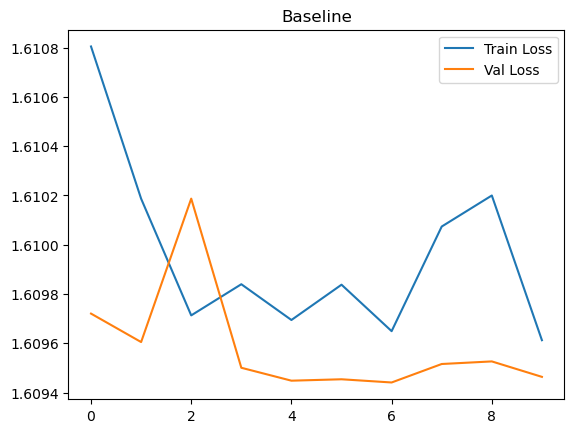

In [9]:
results = []

results.append(train_and_evaluate(
    "Baseline",
    lstm_units=128,
    dropout=0.3,
    embedding_dim=128,
    second_lstm=False
))


===== Exp1_LSTM256 =====
Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - accuracy: 0.6323 - loss: 0.6757 - val_accuracy: 0.8001 - val_loss: 0.2792
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.7936 - loss: 0.3310 - val_accuracy: 0.8001 - val_loss: 0.2785
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.7962 - loss: 0.2809 - val_accuracy: 0.7998 - val_loss: 0.2826
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.8005 - loss: 0.2809 - val_accuracy: 0.8001 - val_loss: 0.2791
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 53s 120ms/step - accuracy: 0.7967 - loss: 0.2800 - val_accuracy: 0.7998 - val_loss: 0.2776
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.7974 - loss: 0.2792 - val_accuracy: 0.8001 - val_loss: 0.2780
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.8011 - loss: 0.2786 - val_accuracy: 0.7998 - val_loss: 0.2782
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accurac

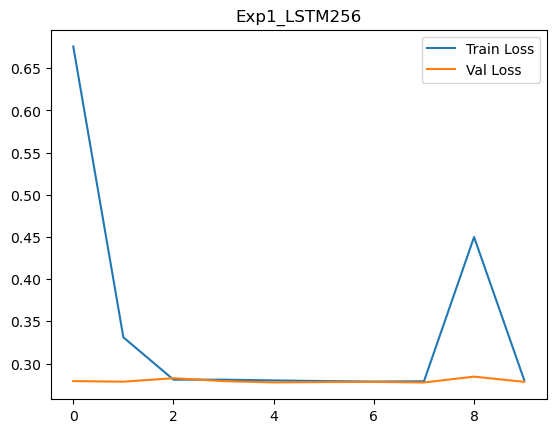

In [10]:
results.append(train_and_evaluate(
    "Exp1_LSTM256",
    lstm_units=256,
    dropout=0.3,
    embedding_dim=128,
    second_lstm=False
))


===== Exp2_Dropout0.5 =====
Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.3715 - loss: 1.2329 - val_accuracy: 0.8001 - val_loss: 0.2834
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8018 - loss: 0.2836 - val_accuracy: 0.7998 - val_loss: 0.2780
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8022 - loss: 0.2811 - val_accuracy: 0.8001 - val_loss: 0.2776
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8010 - loss: 0.2796 - val_accuracy: 0.8001 - val_loss: 0.2785
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7454 - loss: 0.5332 - val_accuracy: 0.8001 - val_loss: 0.2799
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8008 - loss: 0.2809 - val_accuracy: 0.7998 - val_loss: 0.2787
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8019 - loss: 0.2792 - val_accuracy: 0.7998 - val_loss: 0.2840
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accur

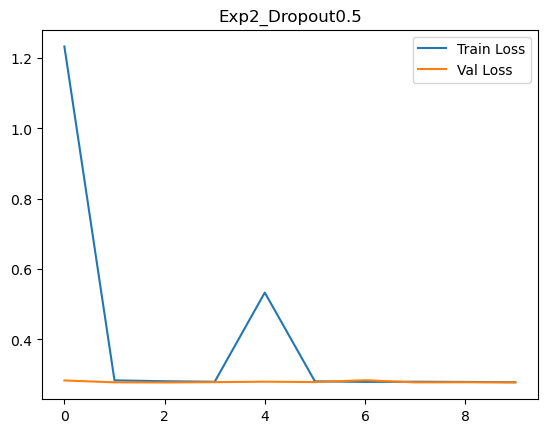

In [11]:
results.append(train_and_evaluate(
    "Exp2_Dropout0.5",
    lstm_units=128,
    dropout=0.5,
    embedding_dim=128,
    second_lstm=False
))


===== Exp3_NoDropout =====
Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.2008 - loss: 1.6102 - val_accuracy: 0.2002 - val_loss: 1.6095
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.1939 - loss: 1.6099 - val_accuracy: 0.1999 - val_loss: 1.6096
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 84s 100ms/step - accuracy: 0.2039 - loss: 1.6099 - val_accuracy: 0.1999 - val_loss: 1.6098
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.1964 - loss: 1.6097 - val_accuracy: 0.1999 - val_loss: 1.6098
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 38s 85ms/step - accuracy: 0.1950 - loss: 1.6097 - val_accuracy: 0.2002 - val_loss: 1.6095
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 47s 99ms/step - accuracy: 0.1947 - loss: 1.6096 - val_accuracy: 0.2002 - val_loss: 1.6094
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accuracy: 0.1943 - loss: 1.6096 - val_accuracy: 0.1999 - val_loss: 1.6094
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accu

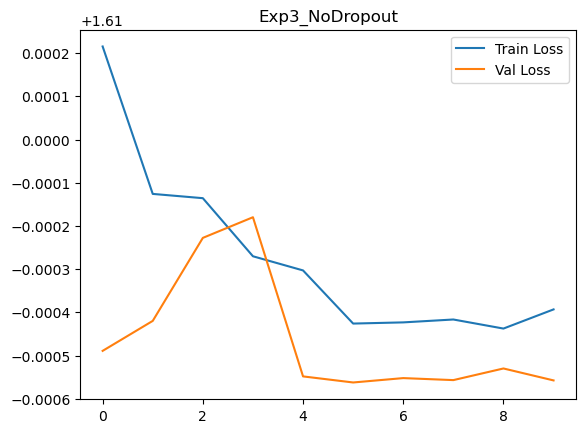

In [12]:
results.append(train_and_evaluate(
    "Exp3_NoDropout",
    lstm_units=128,
    dropout=0.0,
    embedding_dim=128,
    second_lstm=False
))


===== Exp4_2LSTM =====
Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1965 - loss: 1.6110 - val_accuracy: 0.1999 - val_loss: 1.6097
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.5502 - loss: 0.9616 - val_accuracy: 0.7998 - val_loss: 0.2825
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8003 - loss: 0.2816 - val_accuracy: 0.8001 - val_loss: 0.2796
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.8003 - loss: 0.2802 - val_accuracy: 0.8001 - val_loss: 0.2783
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.7982 - loss: 0.2797 - val_accuracy: 0.7998 - val_loss: 0.2779
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.8036 - loss: 0.2789 - val_accuracy: 0.8001 - val_loss: 0.2801
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.8028 - loss: 0.2787 - val_accuracy: 0.7998 - val_loss: 0.2776
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 66s 148ms/step - accuracy:

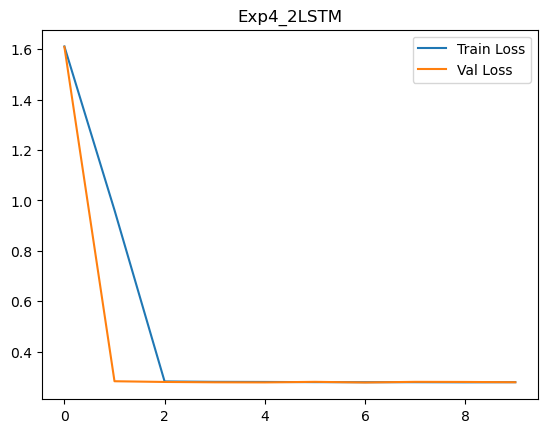

In [13]:
results.append(train_and_evaluate(
    "Exp4_2LSTM",
    lstm_units=128,
    dropout=0.3,
    embedding_dim=128,
    second_lstm=True
))


===== Exp5_Embedding256 =====
Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.2016 - loss: 1.6111 - val_accuracy: 0.2002 - val_loss: 1.6101
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.1977 - loss: 1.6107 - val_accuracy: 0.2002 - val_loss: 1.6095
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.1990 - loss: 1.6099 - val_accuracy: 0.2002 - val_loss: 1.6095
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.1970 - loss: 1.6099 - val_accuracy: 0.1999 - val_loss: 1.6094
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.1999 - loss: 1.6098 - val_accuracy: 0.2002 - val_loss: 1.6102
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.1933 - loss: 1.6098 - val_accuracy: 0.1999 - val_loss: 1.6094
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1965 - loss: 1.6096 - val_accuracy: 0.1999 - val_loss: 1.6094
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - acc

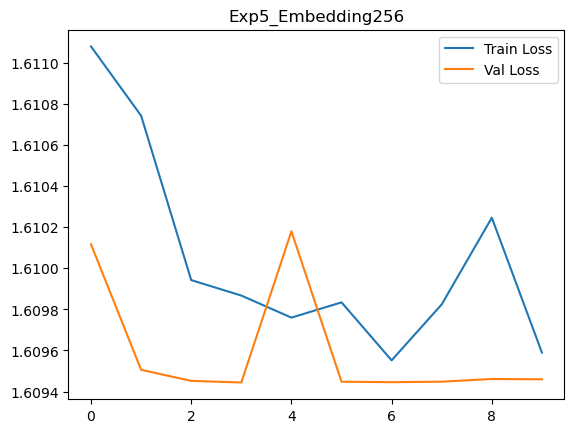

In [14]:
results.append(train_and_evaluate(
    "Exp5_Embedding256",
    lstm_units=128,
    dropout=0.3,
    embedding_dim=256,
    second_lstm=False
))

In [15]:
df = pd.DataFrame(results)
df

df.to_csv("results/tables/results.csv", index=False)

In [16]:
df

,Experiment,Train Loss,Val Loss,Val Accuracy
0,Baseline,1.609613,1.609464,0.199887
1,Exp1_LSTM256,0.280477,0.278290,0.800113
2,Exp2_Dropout0.5,0.278388,0.277697,0.799831
3,Exp3_NoDropout,1.609607,1.609442,0.199887
4,Exp4_2LSTM,0.278724,0.278537,0.799831
5,Exp5_Embedding256,1.609590,1.609460,0.200169


In [48]:
def predict_example(model, text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post')
    
    pred = model.predict(pad, verbose=0)
    return np.argmax(pred) + 1

In [35]:
best_exp = max(results, key=lambda x: x["Val Accuracy"])
best_model_name = best_exp["Experiment"]

print("Best Model:", best_model_name)

Best Model: Exp1_LSTM256


In [42]:
best_model_name = "Exp1_LSTM256"

best_model = build_model(
    lstm_units=256,
    dropout=0.3,
    embedding_dim=128,
    second_lstm=False
)

history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10


C:\Users\Abhisek\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


444/444 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.2038 - loss: 1.6120 - val_accuracy: 0.1999 - val_loss: 1.6107
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 37s 84ms/step - accuracy: 0.1950 - loss: 1.6106 - val_accuracy: 0.1999 - val_loss: 1.6096
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.2000 - loss: 1.6101 - val_accuracy: 0.1999 - val_loss: 1.6095
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 36s 82ms/step - accuracy: 0.2007 - loss: 1.6097 - val_accuracy: 0.2002 - val_loss: 1.6095
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 107s 241ms/step - accuracy: 0.1963 - loss: 1.6096 - val_accuracy: 0.2002 - val_loss: 1.6094
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 63s 142ms/step - accuracy: 0.2012 - loss: 1.6096 - val_accuracy: 0.2002 - val_loss: 1.6095
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 89s 202ms/step - accuracy: 0.2009 - loss: 1.6096 - val_accuracy: 0.1999 - val_loss: 1.6095
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - accuracy: 0.1933 - loss: 1.6096 - val_acc

In [50]:
examples = [
    "She woke up early in the morning.",
    "He rushed to catch the bus.",
    "They enjoyed dinner together.",
    "The sun began to set.",
    "They celebrated their success.",
    "Rambo Rocks Down"
]

for text in examples:
    print(f"\nText: {text}")
    print("Predicted Position:", predict_example(best_model,text))


Text: She woke up early in the morning.
Predicted Position: 2

Text: He rushed to catch the bus.
Predicted Position: 2

Text: They enjoyed dinner together.
Predicted Position: 2

Text: The sun began to set.
Predicted Position: 2

Text: They celebrated their success.
Predicted Position: 2

Text: Rambo Rocks Down
Predicted Position: 2
